In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [15]:
import pandas as pd

# Try different encodings
encodings_to_try = ['latin-1', 'cp1252', 'ISO-8859-1', 'utf-8']

for encoding in encodings_to_try:
    try:
        df = pd.read_csv('data.csv', encoding=encoding)
        print(f"✅ Success! Used encoding: {encoding}")
        print(f"Shape: {df.shape}")
        break
    except (UnicodeDecodeError, pd.errors.ParserError):
        print(f"❌ Failed with encoding: {encoding}")
        continue

✅ Success! Used encoding: latin-1
Shape: (569, 33)


In [16]:
# Load the built-in Breast Cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target') # 0 = Malignant, 1 = Benign

# Display data
display(X.head())
print(f"Dataset shape: {X.shape[0]} samples, {X.shape[1]} features")
print("\nTarget distribution:")
print(y.value_counts(normalize=True).map({0: 'Malignant (Cancer)', 1: 'Benign (Non-Cancer)'}))

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Dataset shape: 569 samples, 30 features

Target distribution:
target
1    NaN
0    NaN
Name: proportion, dtype: str


In [17]:
# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (Crucial for distance-based algorithms like SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")

Training set shape: (455, 30)
Testing set shape: (114, 30)


In [18]:
# 1. Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

# 2. Support Vector Machine (SVM)
svm_model = SVC(probability=True, random_state=42, class_weight='balanced')
svm_model.fit(X_train_scaled, y_train)
svm_preds = svm_model.predict(X_test_scaled)
svm_probs = svm_model.predict_proba(X_test_scaled)[:, 1]

print("Models trained successfully!")

Models trained successfully!


In [19]:
print("="*40)
print("RANDOM FOREST RESULTS")
print("="*40)
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}\n")
print(classification_report(y_test, rf_preds, target_names=data.target_names))

print("="*40)
print("SVM RESULTS")
print("="*40)
print(f"Accuracy: {accuracy_score(y_test, svm_preds):.4f}\n")
print(classification_report(y_test, svm_preds, target_names=data.target_names))

RANDOM FOREST RESULTS
Accuracy: 0.9474

              precision    recall  f1-score   support

   malignant       0.91      0.95      0.93        42
      benign       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114

SVM RESULTS
Accuracy: 0.9649

              precision    recall  f1-score   support

   malignant       0.93      0.98      0.95        42
      benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



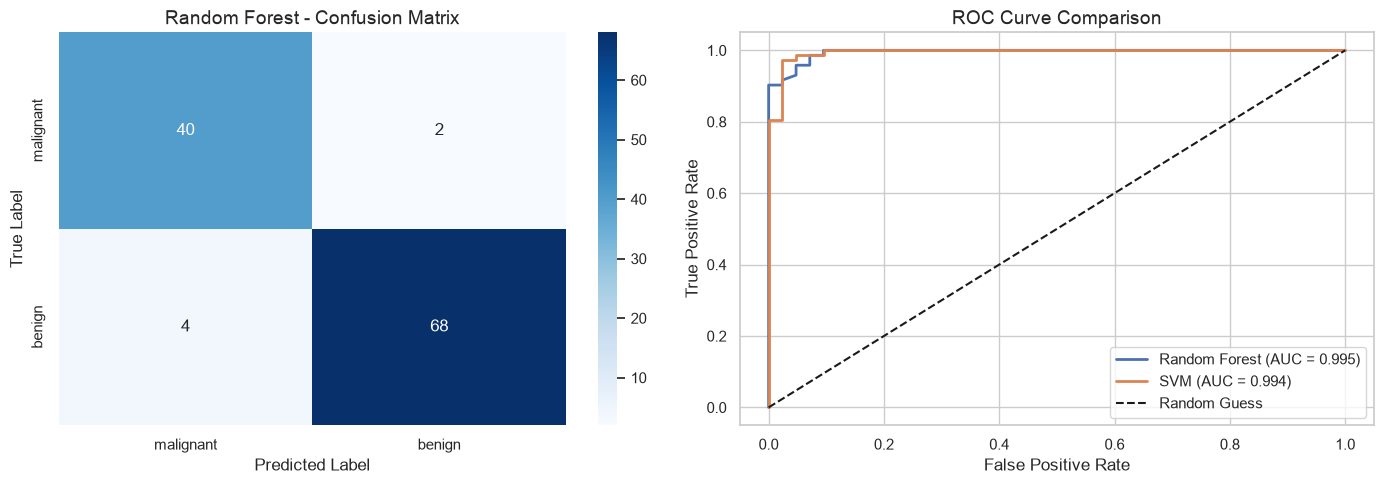

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix (Random Forest)
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=data.target_names, yticklabels=data.target_names)
axes[0].set_title('Random Forest - Confusion Matrix', fontsize=14)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# 2. ROC Curve Comparison
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)

axes[1].plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {auc(rf_fpr, rf_tpr):.3f})', linewidth=2)
axes[1].plot(svm_fpr, svm_tpr, label=f'SVM (AUC = {auc(svm_fpr, svm_tpr):.3f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[1].set_title('ROC Curve Comparison', fontsize=14)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

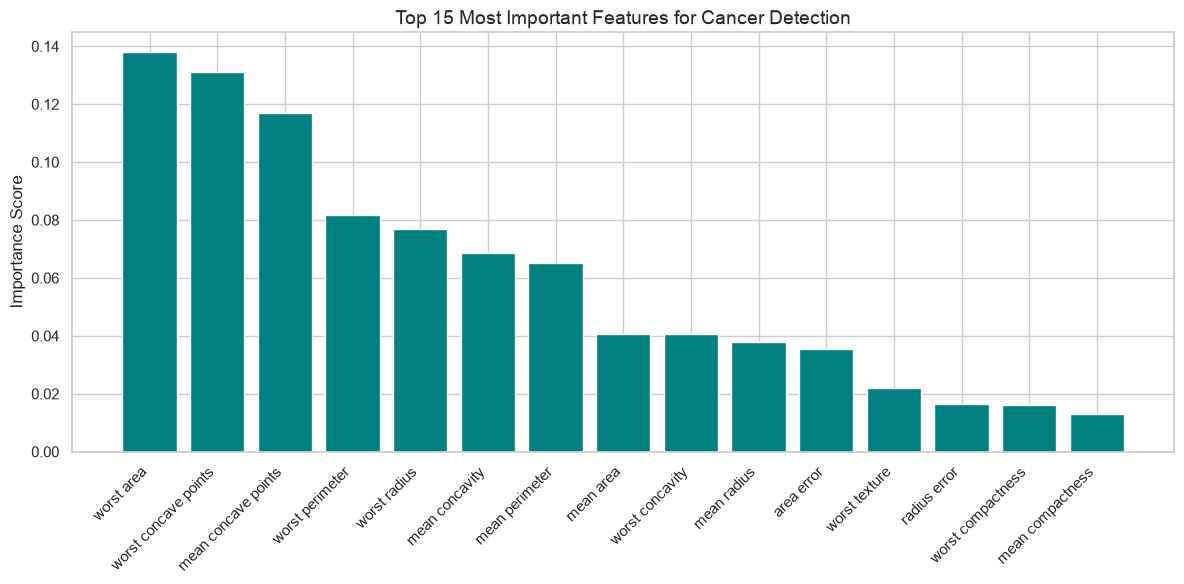

In [21]:
# Extract feature importances from the Random Forest model
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Top 15 Most Important Features for Cancer Detection", fontsize=14)
plt.bar(range(15), importances[indices][:15], align="center", color='teal')
plt.xticks(range(15), [data.feature_names[i] for i in indices[:15]], rotation=45, ha='right')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

In [22]:
# Pick a random patient from the test set to simulate a new diagnosis
test_index = np.random.randint(0, len(X_test_scaled))
new_patient_data = X_test_scaled[test_index].reshape(1, -1)
actual_diagnosis = y_test.iloc[test_index]

# Get prediction and confidence
prediction = rf_model.predict(new_patient_data)[0]
probability = rf_model.predict_proba(new_patient_data)[0]

# Map targets to readable strings
diag_map = {0: 'Malignant (Cancerous)', 1: 'Benign (Non-Cancerous)'}

print("--- NEW PATIENT DIAGNOSIS ---")
print(f"Model Prediction : {diag_map[prediction]}")
print(f"Model Confidence : {max(probability)*100:.2f}%")
print(f"Actual Diagnosis : {diag_map[actual_diagnosis]}")

--- NEW PATIENT DIAGNOSIS ---
Model Prediction : Benign (Non-Cancerous)
Model Confidence : 100.00%
Actual Diagnosis : Benign (Non-Cancerous)
